In [ ]:
Compare the top 5 European Leagues across 
Notes: The wages (from footystats) are estimates for each team meaning that financial decision made from these findings are not realstic 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from pandas.plotting import parallel_coordinates
from sklearn.cluster import KMeans

In [2]:
england = pd.read_csv(r"C:\Users\H.P\Downloads\Top 5 Soccer Euro League Comparison Analysis\Raw_top5_euro_leagues_teams_stats\premierleague_team_stats.csv", sep = ";")
france = pd.read_csv(r"C:\Users\H.P\Downloads\Top 5 Soccer Euro League Comparison Analysis\Raw_top5_euro_leagues_teams_stats\ligue1_team_stats.csv", sep = ";")
germany = pd.read_csv(r"C:\Users\H.P\Downloads\Top 5 Soccer Euro League Comparison Analysis\Raw_top5_euro_leagues_teams_stats\bundesliga_team_stats.csv", sep = ";")
italy = pd.read_csv(r"C:\Users\H.P\Downloads\Top 5 Soccer Euro League Comparison Analysis\Raw_top5_euro_leagues_teams_stats\serieA_team_stats.csv", sep = ";")
spain = pd.read_csv(r"C:\Users\H.P\Downloads\Top 5 Soccer Euro League Comparison Analysis\Raw_top5_euro_leagues_teams_stats\laliga_team_stats.csv", sep = ";")
salaries = pd.read_csv(r"C:\Users\H.P\Downloads\Top 5 Soccer Euro League Comparison Analysis\Raw_top5_euro_leagues_teams_stats\Salaries.csv", sep = ";")

In [3]:
england.insert(0, "League", "England")
france.insert(0, "League", "France")
germany.insert(0, "League", "Germany")
italy.insert(0, "League", "Italy")
spain.insert(0, "League", "Spain")

In [4]:
france.head(5)

,League,Team Name,goals_team_match_Total,goals_team_match_Value,goals_conceded_team_match_Total,goals_conceded_team_match_Value,possession_percentage_team_Total,possession_percentage_team_Value,clean_sheet_team_Total,clean_sheet_team_Value,...,total_tackle_team_Total,total_tackle_team_Value,effective_clearance_team_Total,effective_clearance_team_Value,poss_won_att_3rd_team_Total,poss_won_att_3rd_team_Value,penalty_conceded_team_Total,penalty_conceded_team_Value,saves_team_Total,saves_team_Value
0,France,Angers,29,0.9,48,1.4,29,41.9,34,10,...,612,18.0,779,22.9,580,3.1,3,6,137,4.0
1,France,Auxerre,34,1.0,44,1.3,34,43.9,34,9,...,615,18.1,753,22.1,638,3.6,3,5,112,3.3
2,France,Brest,43,1.3,55,1.6,43,43.4,34,9,...,623,18.3,880,25.9,585,4.7,4,5,103,3.0
3,France,Le Havre,32,0.9,44,1.3,32,46.8,34,8,...,593,17.4,861,25.3,597,3.3,6,8,99,2.9
4,France,Lens,66,1.9,35,1.0,66,51.1,34,12,...,637,18.7,702,20.6,763,5.3,3,6,82,2.4


In [5]:
df = pd.concat([england, france, germany, italy, spain], axis = 0)

intial_dict = {'Team Name': 'Team', 'goals_team_match_Total', 'goals_team_match_Value', 'goals_conceded_team_match_Total', 
'goals_conceded_team_match_Value', 'possession_percentage_team_Total', 'possession_percentage_team_Value', 
'clean_sheet_team_Total', 'clean_sheet_team_Value', 'ontarget_scoring_att_team_Total_x', 'ontarget_scoring_att_team_Value_x', 'expected_goals_team_Total', 'expected_goals_team_Value', '_xg_diff_team_Total', '_xg_diff_team_Value', 'ontarget_scoring_att_team_Total_y', 'ontarget_scoring_att_team_Value_y', 'big_chance_team_Total', 'big_chance_team_Value', 'big_chance_missed_team_Total', 'big_chance_missed_team_Value', 'accurate_pass_team_Total', 'accurate_pass_team_Value', 'accurate_long_balls_team_Total', 'accurate_long_balls_team_Value', 'accurate_cross_team_Total', 'accurate_cross_team_Value', 'penalty_won_team_Total', 'penalty_won_team_Value', 'touches_in_opp_box_team_Value', 'corner_taken_team_Value', '_set_piece_goals_team_Total', '_set_piece_goals_team_Value', 'expected_goals_conceded_team_Total', 'expected_goals_conceded_team_Value', 'interception_team_Total', 'interception_team_Value', 'total_tackle_team_Total', 'total_tackle_team_Value', 'effective_clearance_team_Total', 'effective_clearance_team_Value', 'poss_won_att_3rd_team_Total', 'poss_won_att_3rd_team_Value', '_set_piece_goals_conceded_team_Total', '_set_piece_goals_conceded_team_Value', 'penalty_conceded_team_Total', 'penalty_conceded_team_Value', 'saves_team_Total', 'saves_team_Value', 'fk_foul_lost_team_Total', 'fk_foul_lost_team_Value', 'total_yel_card_team_Total', 'total_yel_card_team_Value', 'total_red_card_team_Total', 'total_red_card_team_Value'

In [7]:
df.columns

Index(['League', 'Team Name', 'goals_team_match_Total',
       'goals_team_match_Value', 'goals_conceded_team_match_Total',
       'goals_conceded_team_match_Value', 'possession_percentage_team_Total',
       'possession_percentage_team_Value', 'clean_sheet_team_Total',
       'clean_sheet_team_Value', 'ontarget_scoring_att_team_Total',
       'ontarget_scoring_att_team_Value', 'expected_goals_team_Total',
       'expected_goals_team_Value', 'big_chance_team_Total',
       'big_chance_team_Value', 'big_chance_missed_team_Total',
       'big_chance_missed_team_Value', 'accurate_pass_team_Total',
       'accurate_pass_team_Value', 'accurate_long_balls_team_Total',
       'accurate_long_balls_team_Value', 'accurate_cross_team_Total',
       'accurate_cross_team_Value', 'penalty_won_team_Total',
       'penalty_won_team_Value', 'touches_in_opp_box_team_Value',
       'corner_taken_team_Value', 'expected_goals_conceded_team_Total',
       'expected_goals_conceded_team_Value', 'interception_

In [8]:
#Drop columns
columns_to_drop = ['possession_percentage_team_Total', 'clean_sheet_team_Total',
'expected_goals_team_Total', 'big_chance_team_Total',
'big_chance_missed_team_Total', 'expected_goals_conceded_team_Total']
df = df.drop(columns = columns_to_drop)

In [9]:
#Rename columns
dictionary = {'Team Name': 'Team', 'goals_team_match_Total': 'Goals_scored', 'goals_team_match_Value': 'Goals_scored/90',
       'goals_conceded_team_match_Total': 'Goals_conceded' , 'goals_conceded_team_match_Value': 'Goals_conceded/90',
       'possession_percentage_team_Value': 'Possession(%)', 'clean_sheet_team_Value': 'Clean_sheets',
       'ontarget_scoring_att_team_Total': 'Shot_conversion_rate(%)', 'ontarget_scoring_att_team_Value': 'Shots_on_target/90',
       'expected_goals_team_Value': 'xG' , '_xg_diff_team_Total' : 'Goal_difference', '_xg_diff_team_Value' : 'xG_difference', 
        'big_chance_team_Value': 'Big_chances', 'big_chance_missed_team_Value': 'Big_chances_missed', 
        'accurate_pass_team_Total': 'Pass(%)', 'accurate_pass_team_Value': 'Accurate_passes/90', 
        'accurate_long_balls_team_Total': 'Long_balls_success(%)', 'accurate_long_balls_team_Value': 'Accurate_long_balls/90', 
        'accurate_cross_team_Total': 'Crosses(%)' , 'accurate_cross_team_Value': 'Accurate_crosses/90', 
        'penalty_won_team_Total': 'Penalty_conversion_rate(%)',  'penalty_won_team_Value': 'Penalties_won', 
        'touches_in_opp_box_team_Value': 'Touches_in_opposition_box',
       'corner_taken_team_Value': 'Corners', 
        '_set_piece_goals_team_Total': 'xG_set_pieces', '_set_piece_goals_team_Value': 'Set_pieces_goals', 
         'expected_goals_conceded_team_Value': 'xG_conceded', 
        'interception_team_Total': 'Total_interceptions', 'interception_team_Value': 'Interceptions/90', 
        'total_tackle_team_Total': 'Total_tackles', 'total_tackle_team_Value': 'Tackles/90',
        'effective_clearance_team_Total': 'Total_clearances', 'effective_clearance_team_Value': 'Clearances/90', 
        'poss_won_att_3rd_team_Total': 'Total_possession_won_midfield', 'poss_won_att_3rd_team_Value': 'Possession_won_attacking_3rd/90' , 
        '_set_piece_goals_conceded_team_Total': 'xG_set_pieces_conceded', '_set_piece_goals_conceded_team_Value': 'Set_pieces_goals_conceded', 
        'penalty_conceded_team_Total': 'Penalty_goals_conceded', 'penalty_conceded_team_Value': 'Penalties_conceded', 
        'saves_team_Total': 'Total_saves', 'saves_team_Value': 'Saves/90'}

df = df.rename(columns = dictionary)

In [10]:
df = df.merge(salaries, how = 'left', on = ['League', 'Team'])

In [11]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.isnull().sum()

League                             0
Team                               0
Goals_scored                       0
Goals_scored/90                    0
Goals_conceded                     0
Goals_conceded/90                  0
Possession(%)                      0
Clean_sheets                       0
Shot_conversion_rate(%)            0
Shots_on_target/90                 0
xG                                 0
Big_chances                        0
Big_chances_missed                 0
Pass(%)                            0
Accurate_passes/90                 0
Long_balls_success(%)              0
Accurate_long_balls/90             0
Crosses(%)                         0
Accurate_crosses/90                0
Penalty_conversion_rate(%)         2
Penalties_won                      2
Touches_in_opposition_box          0
Corners                            0
xG_conceded                        0
Total_interceptions                0
Interceptions/90                   0
Total_tackles                      0
T

In [14]:
df = df.fillna(0)

In [23]:
df.dtypes

League                              object
Team                                object
Goals_scored                         int64
Goals_scored/90                    float64
Goals_conceded                       int64
Goals_conceded/90                  float64
Possession(%)                      float64
Clean_sheets                         int64
Shot_conversion_rate(%)            float64
Shots_on_target/90                 float64
xG/90                              float64
Big_chances/90                     float64
Big_chances_missed/90              float64
Pass(%)                            float64
Accurate_passes/90                 float64
Long_balls_success(%)              float64
Accurate_long_balls/90             float64
Crosses(%)                         float64
Accurate_crosses/90                float64
Penalty_conversion_rate(%)         float64
Penalties_won                      float64
Touches_in_opposition_box/90       float64
Corners/90                         float64
xG_conceded

In [15]:
#Certain leagues only have 18 teams instead of 20 in most case leading to 34 games in total instead of 38 in a season

# Define the columns to normalize
to_90min = [
    'Big_chances', 'Big_chances_missed',
    'Touches_in_opposition_box', 'Corners', 
    'Total_possession_won_midfield', 'xG', 'xG_conceded'
]

match34 = ['Germany', 'France']

# Create a divisor series: 34 if League is in match34, otherwise 38
divisors = np.where(df['League'].isin(match34), 34, 38)

# Apply division and rounding across those columns efficiently
df[to_90min] = (df[to_90min].div(divisors, axis=0)).round(1)

to_rename = {'Big_chances': 'Big_chances/90' ,
             'Big_chances_missed': 'Big_chances_missed/90',
       'Touches_in_opposition_box': 'Touches_in_opposition_box/90', 
        'Corners': 'Corners/90' , 
        'Total_possession_won_midfield': 'Possession_won_midfield/90',
           'xG': 'xG/90', 
            'xG_conceded': 'xG_conceded/90'}

df = df.rename(columns= to_rename)

In [16]:
# Big_chances_conversion rate
df['Big_chances_conversion rate'] = (1 - (df['Big_chances_missed/90'] / df['Big_chances/90']))*100
#Attempted crosses
df['Crosses/90'] = df['Accurate_crosses/90'] / (df['Crosses(%)']*0.01)
#Attempted long balls
df['Long_balls/90'] = df['Accurate_long_balls/90'] / (df['Long_balls_success(%)']*0.01)
#Attempted passes
df['Pass/90'] = df['Accurate_passes/90'] / (df['Pass(%)']*0.01)

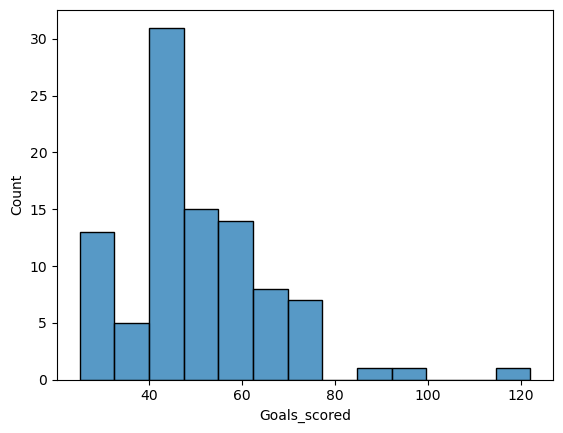

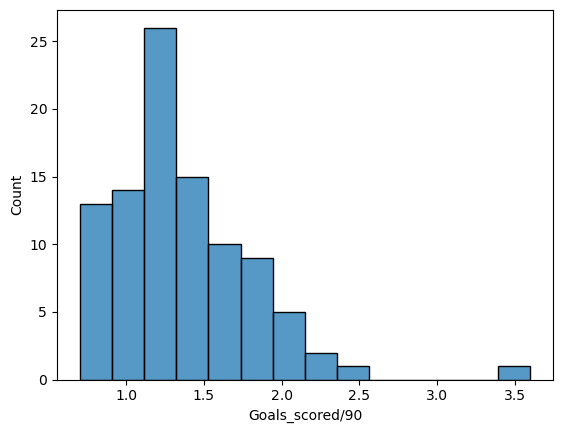

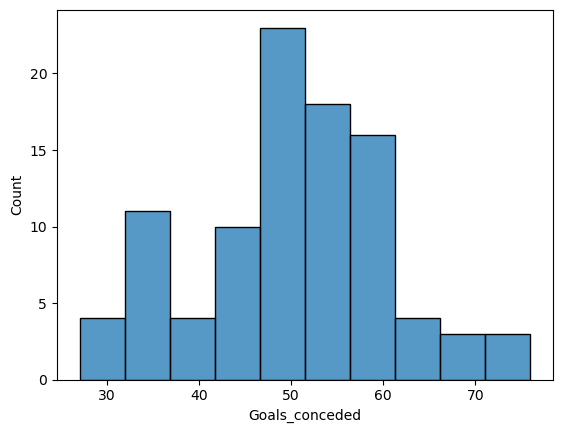

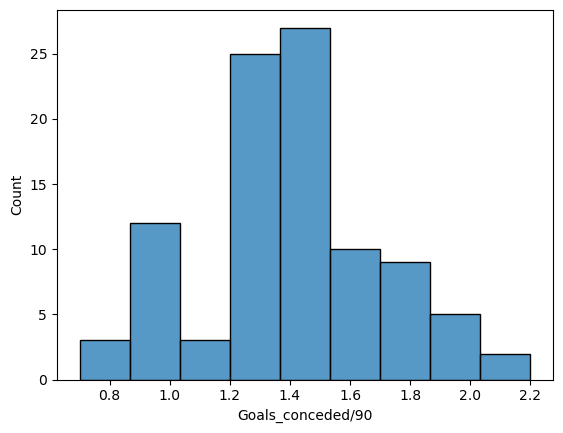

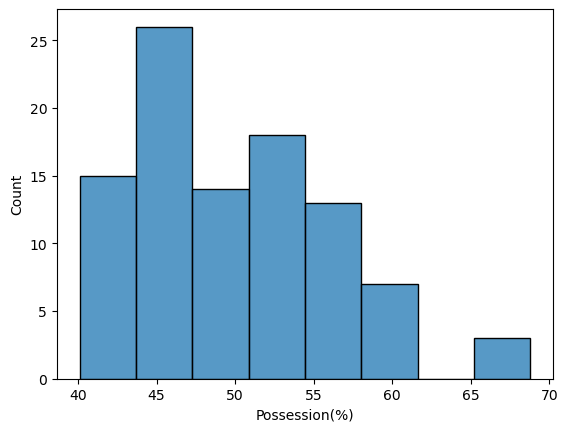

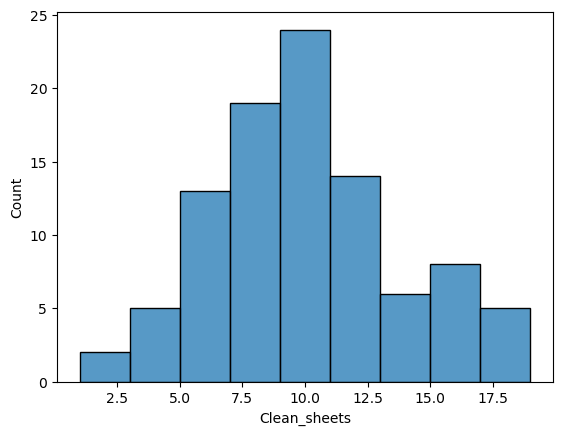

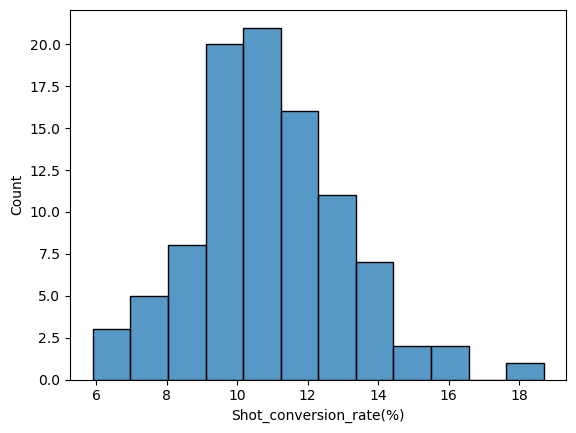

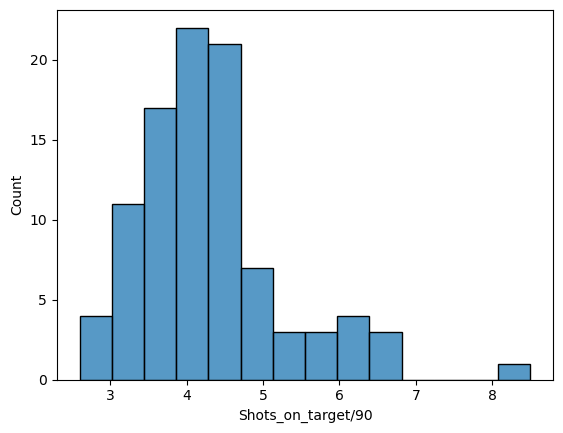

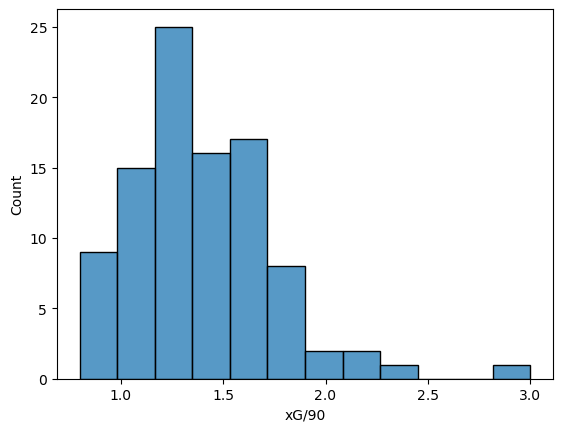

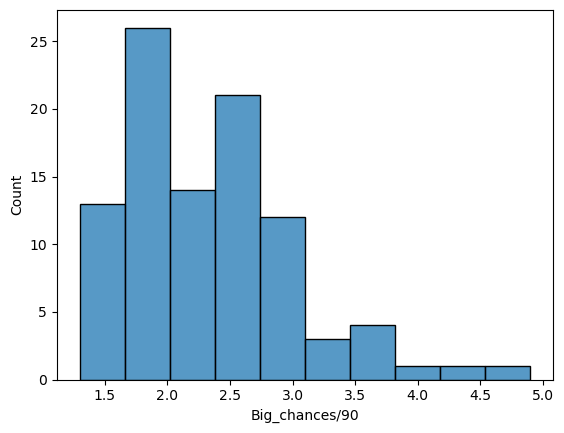

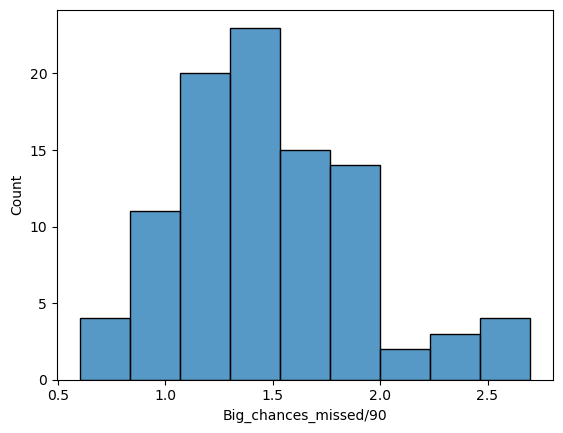

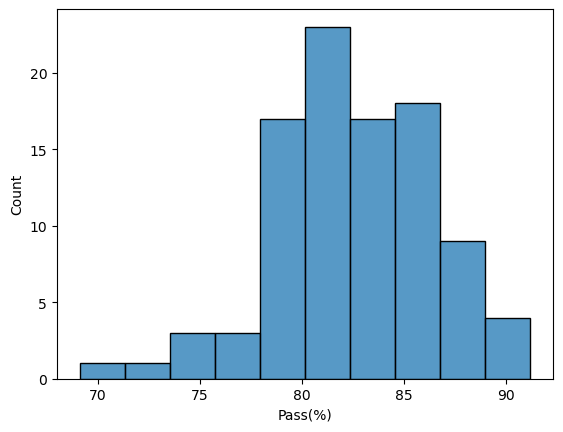

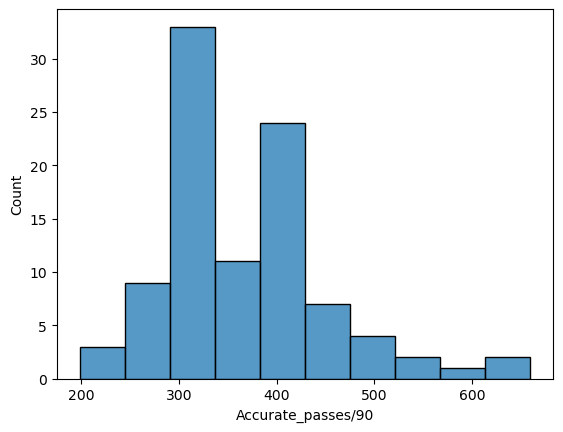

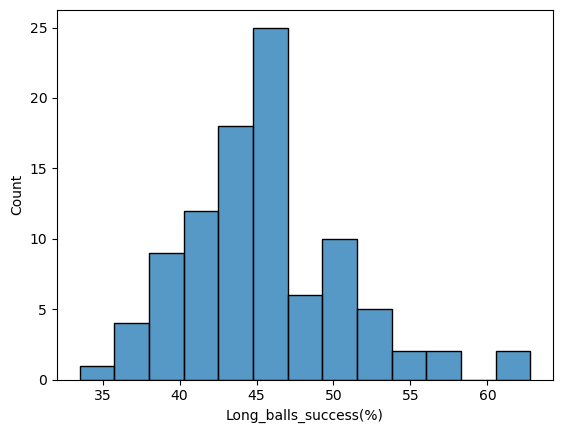

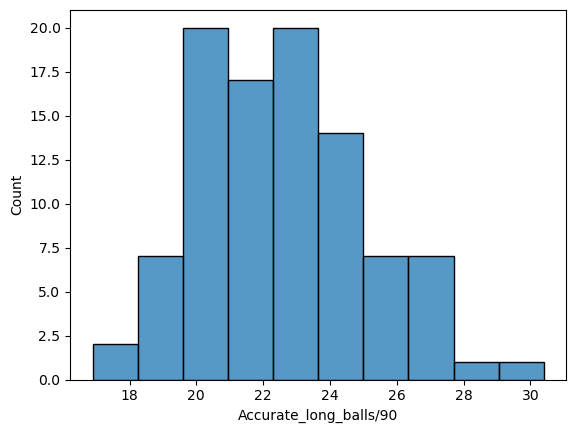

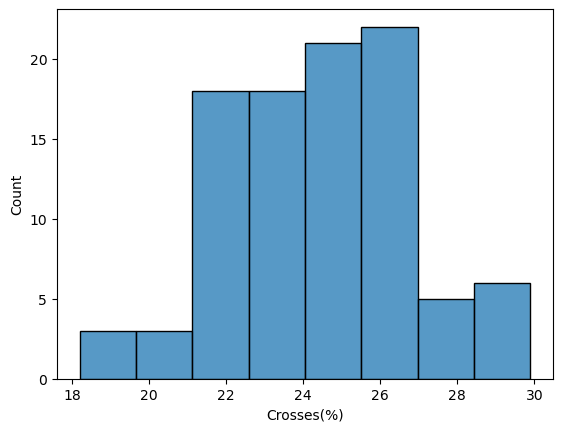

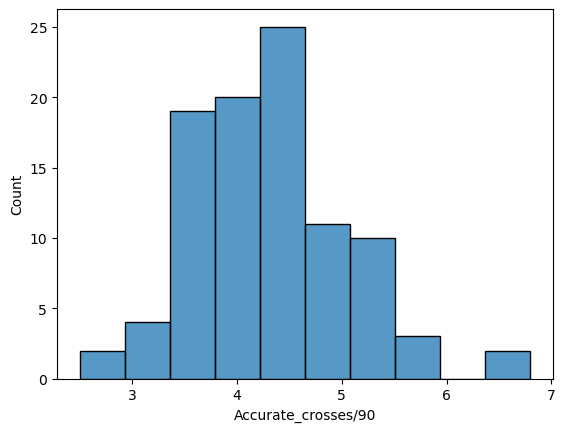

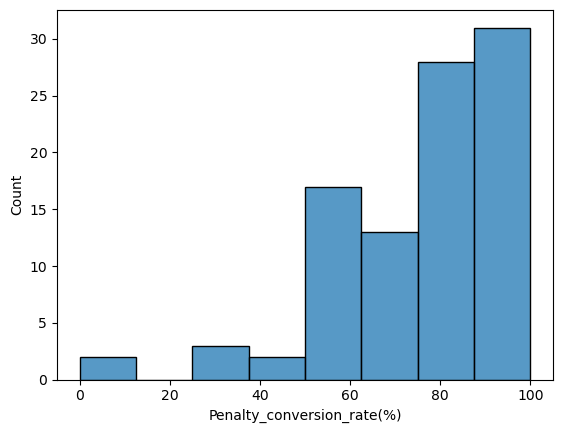

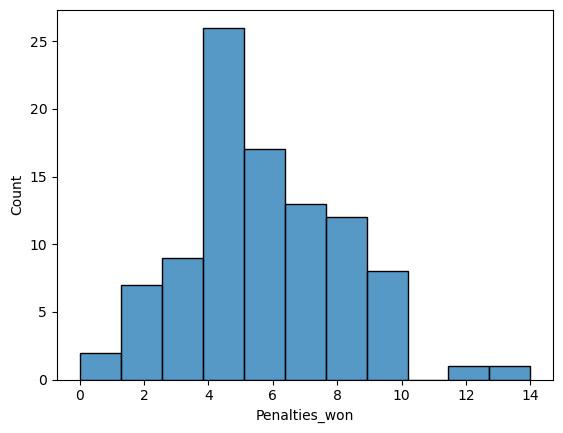

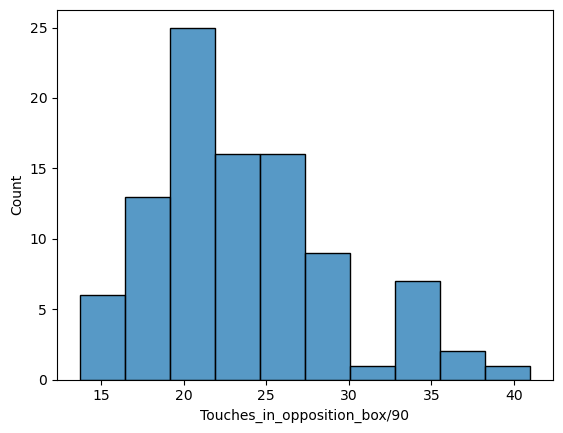

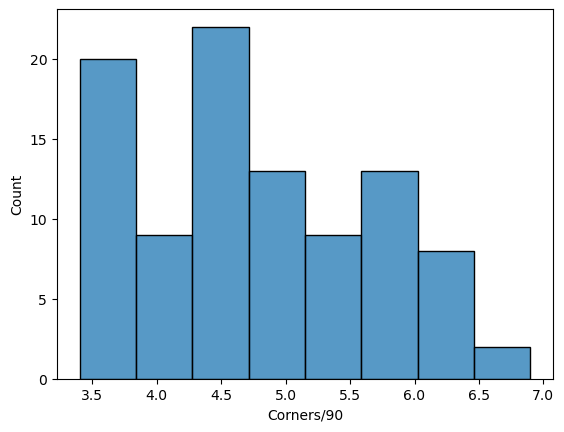

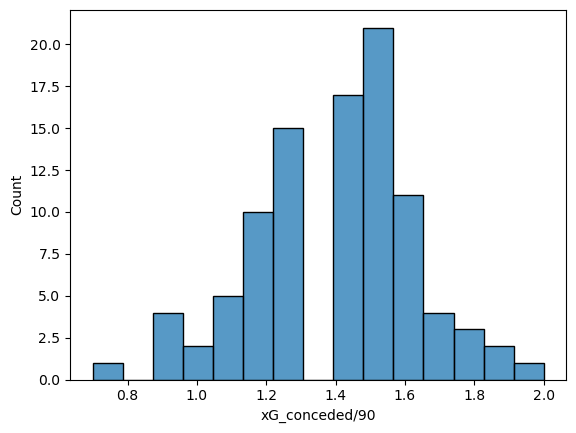

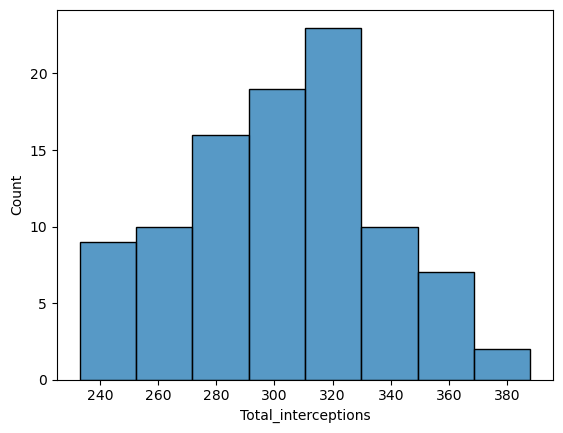

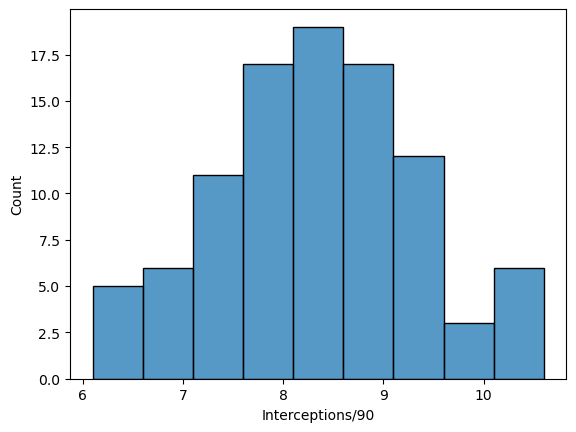

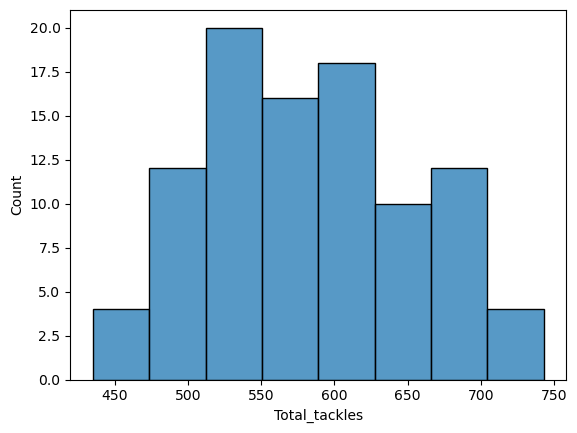

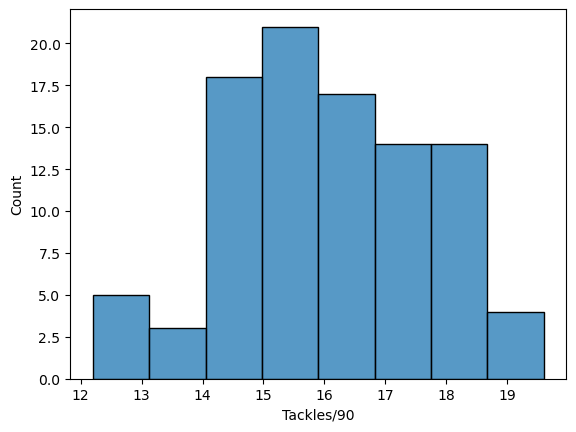

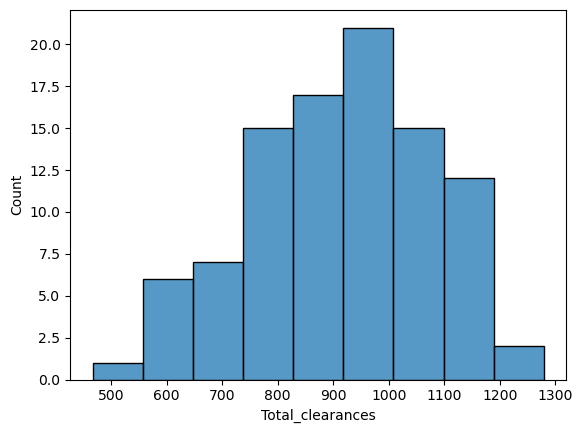

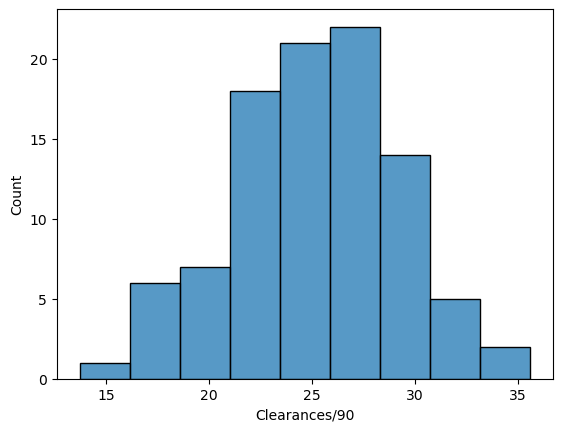

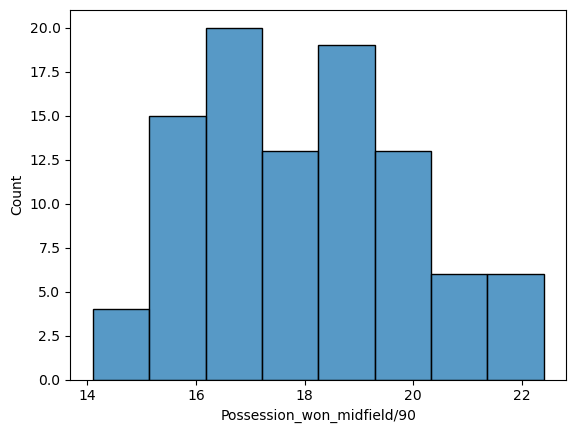

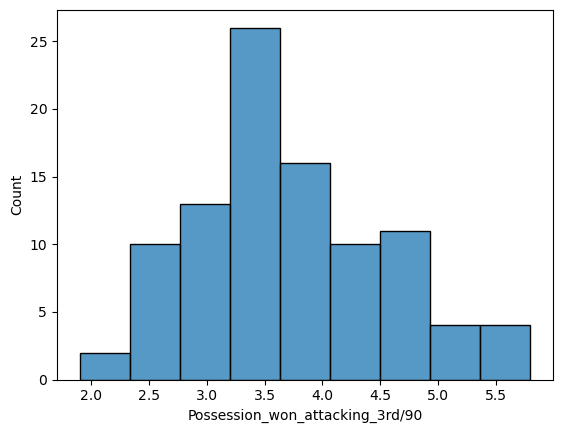

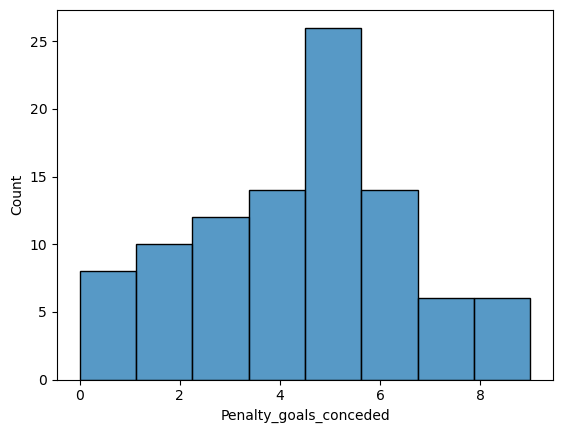

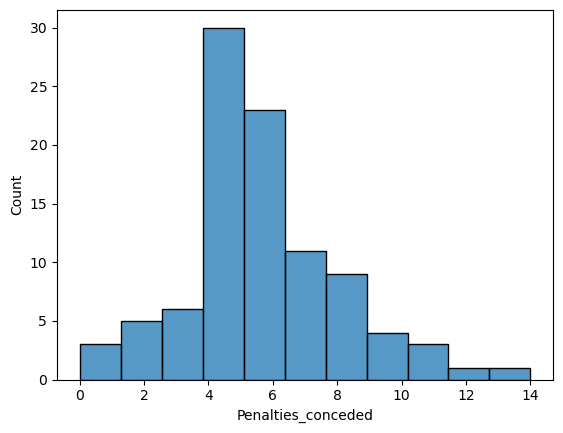

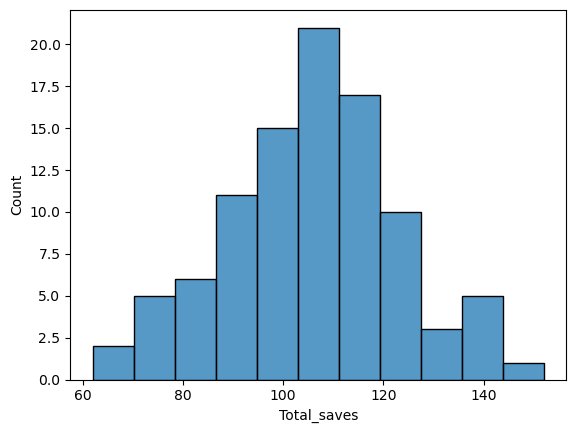

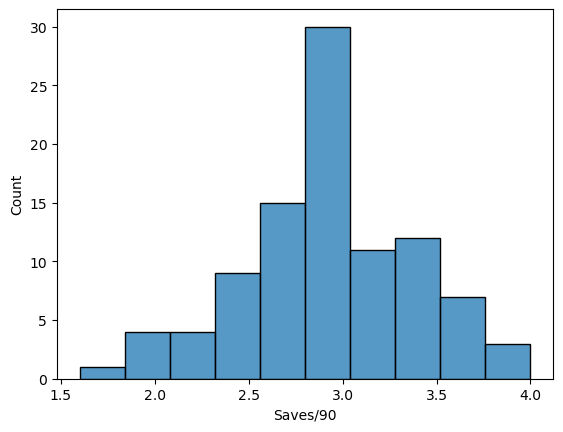

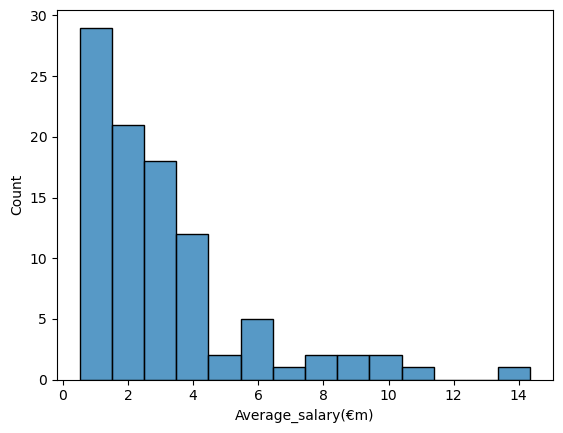

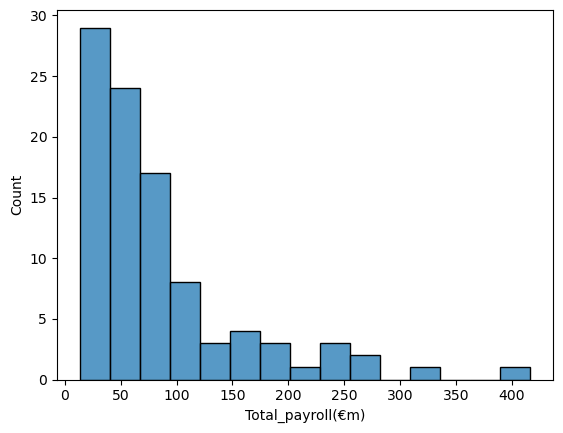

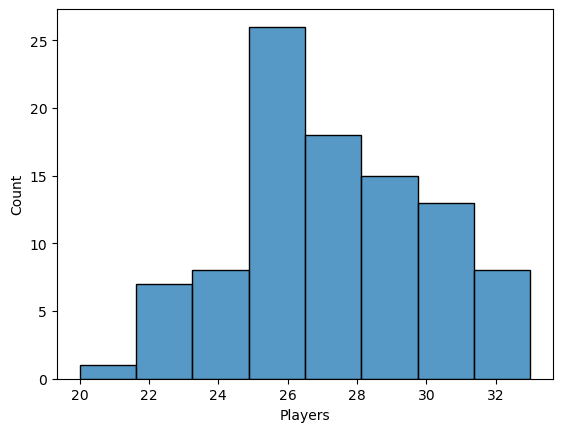

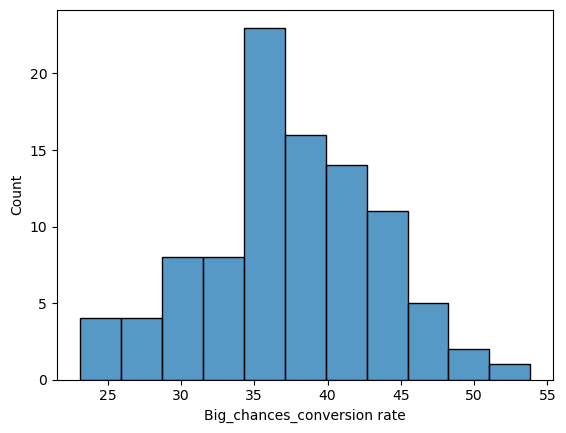

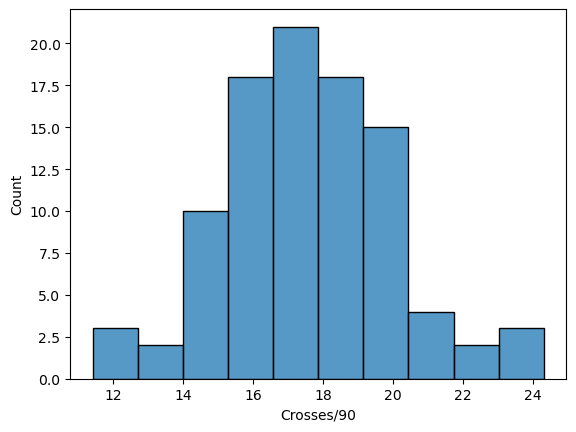

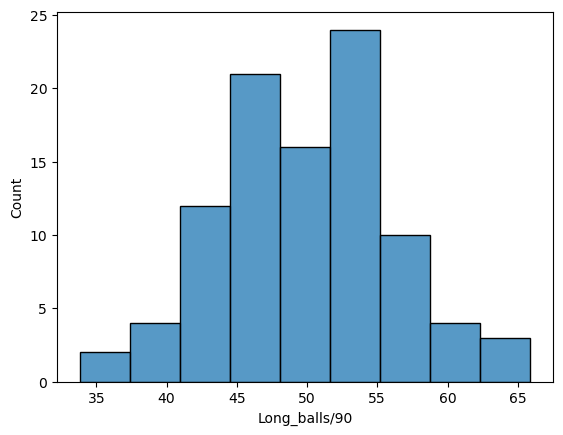

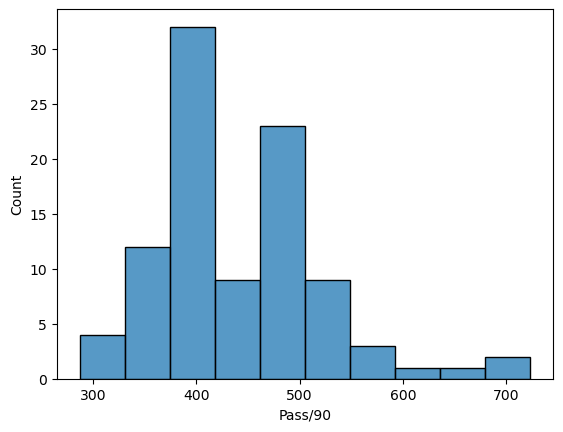

In [17]:
#EDA
distribution = df.drop(columns = ['League', 'Team'])
for element in distribution:
    plt.figure()
    sns.histplot(data = df, x = element)
    plt.show()

Correlation matrix

In [18]:
performance_corr = df[[
    'Goals_scored/90',
    'xG/90',
    'Goals_conceded/90',
    'xG_conceded/90',
    'Shot_conversion_rate(%)',
    'Big_chances_conversion rate' 
]].corr()

gamecontrol_corr = df[[
    'Possession(%)',
    'Pass/90',
    'Long_balls/90',
    'Crosses/90',
    'Clearances/90',
    'Possession_won_midfield/90',
    'Possession_won_attacking_3rd/90',
    'Touches_in_opposition_box/90',
    'Tackles/90',
    'Interceptions/90',
    'Saves/90'
]].corr()

In [ ]:
# 1. Define a larger figure size so everything fits comfortably
plt.figure(figsize=(10, 8))

# 2. Create the heatmap
sns.heatmap(
    performance_corr,
    annot=True, 
    fmt=".2f",         
    cmap="coolwarm",     
    linewidths=0.5,      
    cbar_kws={"shrink": .8} 
)

# 3. Rotate the labels so they don't overlap on the edges
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

# 4. Use tight_layout so nothing gets cut off at the edges
plt.tight_layout()

# plt.savefig("Heatmap correlation.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# 1. Define a larger figure size so everything fits comfortably
plt.figure(figsize=(10, 8))

# 2. Create the heatmap
sns.heatmap(
    gamecontrol_corr,
    annot=True,          
    fmt=".2f",           
    cmap="coolwarm",    
    linewidths=0.5,     
    cbar_kws={"shrink": .8}
)

# 3. Rotate the labels so they don't overlap on the edges
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

# 4. Use tight_layout so nothing gets cut off at the edges
plt.tight_layout()

# plt.savefig("Heatmap correlation.png", dpi=300, bbox_inches='tight')
plt.show()

Having a lot of features that are in addition highly correlated, we are going to use PCA to reduce the dimensionality, use one Principal component thatwould capture most of the variance and eliminate the multicollinearity

In [19]:
# 1. Define your two distinct tactical domains
performance_features = [
    'Goals_scored/90',
    'xG/90',
    'Goals_conceded/90',
    'xG_conceded/90',
    'Shot_conversion_rate(%)',
    'Big_chances_conversion rate' 
]

gamecontrol_features = [
    'Possession(%)',
    'Pass/90',
    'Long_balls/90',
    'Crosses/90',
    'Clearances/90',
    'Possession_won_midfield/90',
    'Possession_won_attacking_3rd/90',
    'Touches_in_opposition_box/90',
    'Tackles/90',
    'Interceptions/90',
    'Saves/90'
]

# 2. Isolate the data and handle missing values safely
X_ad = df[performance_features].copy().fillna(df[performance_features].mean())
X_build = df[gamecontrol_features].copy().fillna(df[gamecontrol_features].mean())

# 3. Standardize both sets separately
scaler = StandardScaler()
X_ad_scaled = scaler.fit_transform(X_ad)
X_build_scaled = scaler.fit_transform(X_build)

# 4. Run TWO separate PCAs (extracting only the 1st component for each)
pca_ad = PCA(n_components=1)
performance_score = pca_ad.fit_transform(X_ad_scaled)

pca_build = PCA(n_components=1)
gamecontrol_score = pca_build.fit_transform(X_build_scaled)

# 5. Combine results into a new plotting DataFrame including 'League'
plot_df = pd.DataFrame({
    'League': df['League'].values,
    'Team': df['Team'].values,
    'Performance_Axis': performance_score.flatten(),
    'Game_Control_Axis': gamecontrol_score.flatten(),
}).reset_index(drop=True)

In [20]:
# --- EXTRACTING WEIGHTS AND VARIANCE ---

# 1. Performance PCA Metrics
perf_loadings = pd.DataFrame(
    pca_ad.components_.T, 
    index=performance_features, 
    columns=['Weight']
)
perf_eigenvalue = pca_ad.explained_variance_[0]
perf_variance_ratio = pca_ad.explained_variance_ratio_[0] * 100

print("--- PERFORMANCE PCA ---")
print(f"Eigenvalue (Variance): {perf_eigenvalue:.3f}")
print(f"Explained Variance Ratio: {perf_variance_ratio:.2f}%\n")
print("Variable Weights (Loadings):")
print(perf_loadings.sort_values(by='Weight', ascending=False))
print("\n" + "="*40 + "\n")

# 2. Game Control PCA Metrics
build_loadings = pd.DataFrame(
    pca_build.components_.T, 
    index=gamecontrol_features, 
    columns=['Weight']
)
build_eigenvalue = pca_build.explained_variance_[0]
build_variance_ratio = pca_build.explained_variance_ratio_[0] * 100

print("--- GAME CONTROL PCA ---")
print(f"Eigenvalue (Variance): {build_eigenvalue:.3f}")
print(f"Explained Variance Ratio: {build_variance_ratio:.2f}%\n")
print("Variable Weights (Loadings):")
print(build_loadings.sort_values(by='Weight', ascending=False))

--- PERFORMANCE PCA ---
Eigenvalue (Variance): 3.442
Explained Variance Ratio: 56.78%

Variable Weights (Loadings):
                               Weight
Goals_scored/90              0.502399
xG/90                        0.470168
Shot_conversion_rate(%)      0.441971
Big_chances_conversion rate  0.250622
xG_conceded/90              -0.364291
Goals_conceded/90           -0.368346


--- GAME CONTROL PCA ---
Eigenvalue (Variance): 5.245
Explained Variance Ratio: 47.18%

Variable Weights (Loadings):
                                   Weight
Possession(%)                    0.402044
Pass/90                          0.391999
Touches_in_opposition_box/90     0.386820
Possession_won_attacking_3rd/90  0.319636
Possession_won_midfield/90       0.294493
Crosses/90                       0.074027
Tackles/90                      -0.145539
Interceptions/90                -0.152319
Saves/90                        -0.295540
Long_balls/90                   -0.297459
Clearances/90                   -0.34

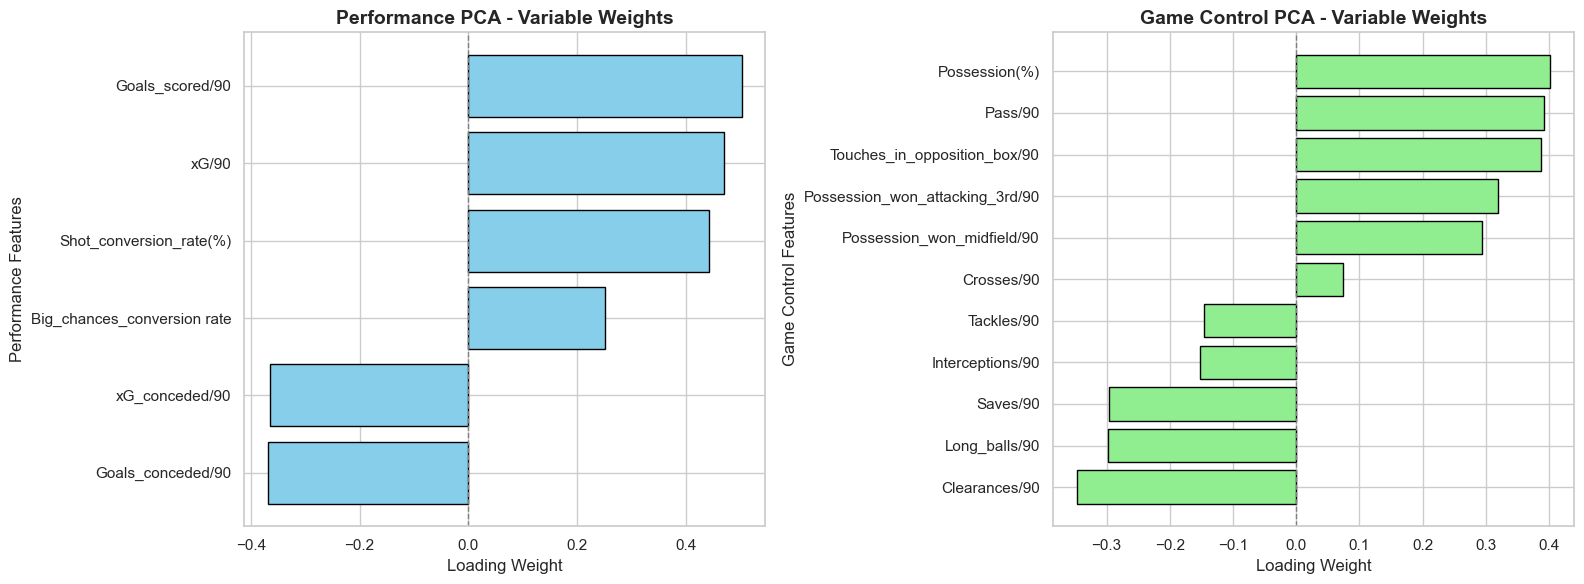

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- 1. PERFORMANCE PCA VARIABLE SHARE (LOADINGS) ---
# Sort loadings for better visualization
perf_sorted = perf_loadings.sort_values(by='Weight', ascending=True)
axes[0].barh(perf_sorted.index, perf_sorted['Weight'], color='skyblue', edgecolor='black')
axes[0].set_title('Performance PCA - Variable Weights', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Loading Weight', fontsize=12)
axes[0].set_ylabel('Performance Features', fontsize=12)
axes[0].axvline(0, color='gray', linestyle='--', linewidth=1)

# --- 2. GAME CONTROL PCA VARIABLE SHARE (LOADINGS) ---
# Sort loadings for better visualization
build_sorted = build_loadings.sort_values(by='Weight', ascending=True)
axes[1].barh(build_sorted.index, build_sorted['Weight'], color='lightgreen', edgecolor='black')
axes[1].set_title('Game Control PCA - Variable Weights', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Loading Weight', fontsize=12)
axes[1].set_ylabel('Game Control Features', fontsize=12)
axes[1].axvline(0, color='gray', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

In [24]:
plot_df = plot_df.merge(df[['Team', 'Average_salary(€m)']], how = 'left', on = 'Team')

League Strength/Level Gap Ranking
    League  Strength_Gap_Score
2  Germany            1.284464
3    Italy            1.259873
1   France            1.069615
4    Spain            0.681961
0  England            0.611801


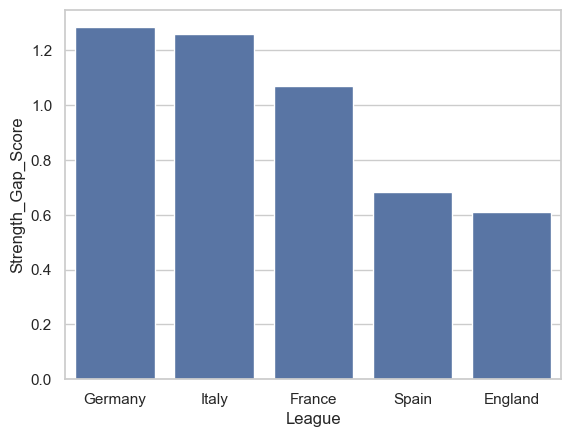

In [25]:
#League Strength Gap
# Calculate Median Absolute Deviation (MAD) for each League
strength_gap = (
    plot_df.groupby('League')['Performance_Axis']
    .apply(lambda x: np.median(np.abs(x - x.median())))
    .reset_index()
)
strength_gap = strength_gap.rename(
    columns={'Performance_Axis': 'Strength_Gap_Score'}
)
print('League Strength/Level Gap Ranking')
print(strength_gap.sort_values(by='Strength_Gap_Score', ascending=False))

plt.figure()
sns.barplot(data = strength_gap.sort_values(by='Strength_Gap_Score', ascending=False), x = 'League', y = 'Strength_Gap_Score')
plt.show()

Spain and England appear have the most difficult/balanced league, the level gap between its is very narrow compared to the others leagues. 
Italy appears to be the the most unbalanced league with a lot of teams that struggle they have five teams below -2 Performance_Score while other leagues have either 2 or 3 teams really struggling.

League Diversity Ranking
    League  Tactical_Diversity_Score
1   France                  1.897724
3    Italy                  1.820948
2  Germany                  1.492299
0  England                  1.433969
4    Spain                  0.644317


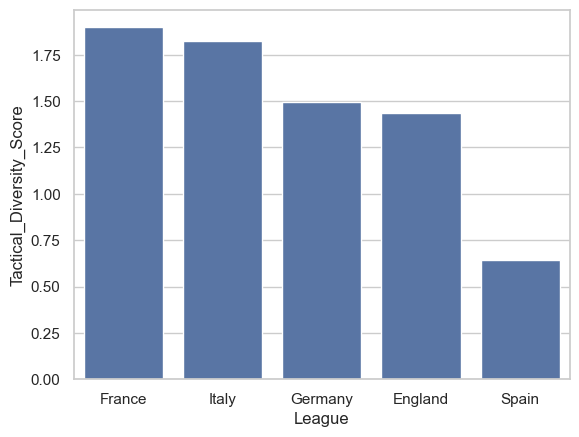

In [26]:
#League Tactical Diversity
# Calculate Median Absolute Deviation (MAD) for each League
tactical_diversty = (
    plot_df.groupby('League')['Game_Control_Axis']
    .apply(lambda x: np.median(np.abs(x - x.median())))
    .reset_index()
)
tactical_diversty = tactical_diversty.rename(
    columns={'Game_Control_Axis': 'Tactical_Diversity_Score'}
)
print('League Diversity Ranking')
print(tactical_diversty.sort_values(by='Tactical_Diversity_Score', ascending=False))
plt.figure()
sns.barplot(data = tactical_diversty.sort_values(by='Tactical_Diversity_Score', ascending=False), x = 'League', y = 'Tactical_Diversity_Score')
plt.show()

Spain has the lowest diversity adopting a pretty similar approach on how they control/react to the games
They have 6 teams out 20 in  the -0.5 and 0.5 range while other teams just have around 1 to 2 teams within that same range
(*not a define style balanced between reactive and proactive)


 RUNNING K-MEANS ELBOW METHOD FOR: GAME_CONTROL


C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with M

  -> Testing K = 1 | Inertia = 1056.0000
  -> Testing K = 2 | Inertia = 697.0852
  -> Testing K = 3 | Inertia = 618.5534
  -> Testing K = 4 | Inertia = 543.7464
  -> Testing K = 5 | Inertia = 502.4762
  -> Testing K = 6 | Inertia = 470.6401
  -> Testing K = 7 | Inertia = 448.7178


C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


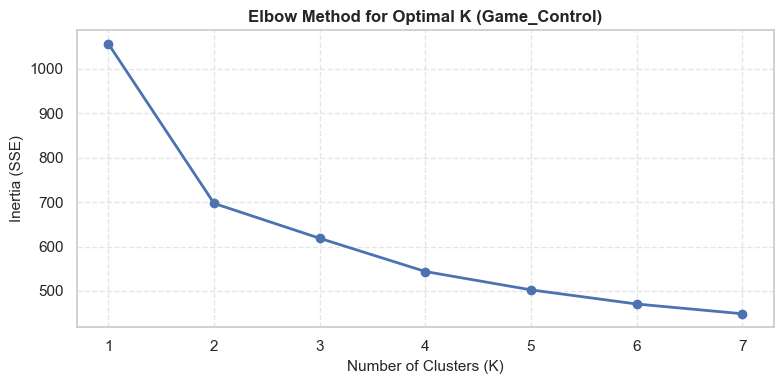

Enter the optimal K you chose from the elbow graph for Game_Control:  4


C:\Users\H.P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



### Teams Grouped by Game_Control Playstyle (K=4) ###
Cluster 0: Brentford, Burnley, Crystal Palace, Everton, Leeds United, Nottingham Forest, West Ham United, Wolverhampton Wanderers, Angers, Auxerre, Brest, Le Havre, Nantes, Nice, Augsburg, Borussia Monchengladbach, FC Heidenheim, Hamburger SV, Mainz 05, St. Pauli, Union Berlin, Werder Bremen, Wolfsburg, Hellas Verona, Lecce, Pisa, Torino, Deportivo Alaves, Espanyol, Getafe, Levante, Rayo Vallecano, Real Betis, Real Oviedo, Real Sociedad, Sevilla
Cluster 1: Arsenal, Liverpool, Manchester City, Marseille, Paris Saint-Germain, Strasbourg, Bayer Leverkusen, Bayern Munchen, Como, Inter, Juventus, Napoli, Barcelona, Real Madrid
Cluster 2: AFC Bournemouth, Brighton & Hove Albion, Chelsea, Manchester United, Newcastle United, Tottenham Hotspur, Lens, Lille, Monaco, Rennes, Toulouse, Borussia Dortmund, Hoffenheim, RB Leipzig, VfB Stuttgart, Atalanta, Roma, Athletic Club, Atletico Madrid
Cluster 3: Aston Villa, Fulham, Sunderland, Lorient, L

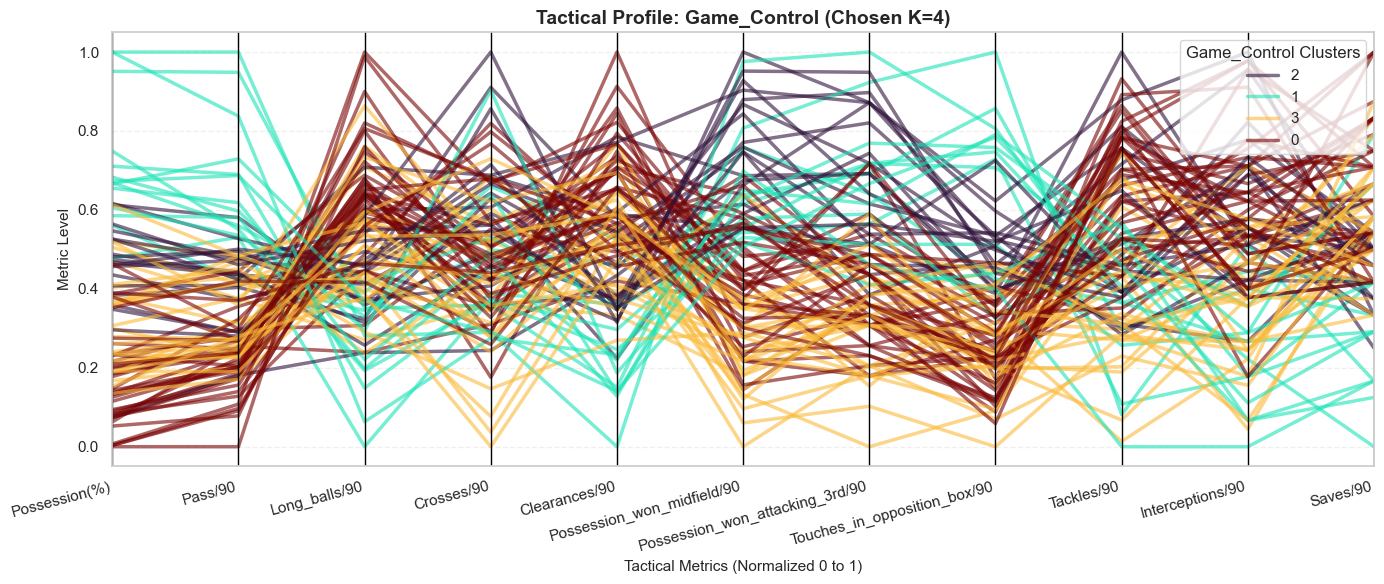

In [28]:
# 1. Define the updated single feature set for game control
gamecontrol_features = [
    'Possession(%)',
    'Pass/90',
    'Long_balls/90',
    'Crosses/90',
    'Clearances/90',
    'Possession_won_midfield/90',
    'Possession_won_attacking_3rd/90',
    'Touches_in_opposition_box/90',
    'Tackles/90',
    'Interceptions/90',
    'Saves/90'
]


# 2. Reusable pipeline function updated to use the ELBOW METHOD
def run_tactical_clustering_elbow(df_input, features, phase_name):
  print(f'\n' + '=' * 50)
  print(f' RUNNING K-MEANS ELBOW METHOD FOR: {phase_name.upper()}')
  print(f'==================================================')

  # Ensure 'Team' is present to use as a label by resetting index if needed
  if 'Team' not in df_input.columns:
    df_input = df_input.reset_index()
    if 'Team' not in df_input.columns:
      df_input.rename(columns={df_input.columns[0]: 'Team'}, inplace=True)

  # Create a clean copy with 'Team' and the specified features
  df_phase = df_input[['Team'] + features].copy()

  # Extract features for clustering and handle missing values
  X = df_phase[features].copy()
  X = X.fillna(X.mean())

  # Standardize the features (crucial for accurate distance metrics)
  scaler = StandardScaler()
  X_scaled = scaler.fit_transform(X)

  # Set the range for K evaluation based on dataset size
  max_k = min(7, len(df_phase) - 1)
  k_range = range(1, max_k + 1)  # Elbow usually starts K at 1

  if len(k_range) == 0:
    print('Error: Not enough teams to perform clustering.')
    return df_phase

  inertia_values = []

  # Evaluate inertia (Sum of Squared Errors) for each K
  for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)
    print(f'  -> Testing K = {k} | Inertia = {kmeans.inertia_:.4f}')

  # Plot the Elbow Curve
  plt.figure(figsize=(8, 4))
  plt.plot(k_range, inertia_values, marker='o', linestyle='-', color='b', lw=2)
  plt.title(
      f'Elbow Method for Optimal K ({phase_name})',
      fontsize=12,
      fontweight='bold',
  )
  plt.xlabel('Number of Clusters (K)', fontsize=11)
  plt.ylabel('Inertia (SSE)', fontsize=11)
  plt.grid(True, linestyle='--', alpha=0.5)
  plt.xticks(k_range)
  plt.tight_layout()
  plt.show()

  # Prompt user or hardcode choice based on visual inspection of the graph
  # For demonstration continuation, let's allow setting 'best_k' manually after viewing, 
  # or default to a safe choice like 3.
  best_k = int(
      input(
          f'Enter the optimal K you chose from the elbow graph for {phase_name}:'
          ' '
      )
  )

  # Run final K-Means with the chosen optimal K
  final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
  cluster_col = f'Cluster_{phase_name}'
  df_phase[cluster_col] = final_kmeans.fit_predict(X_scaled)

  # Output the teams belonging to each cluster
  print(f'\n### Teams Grouped by {phase_name} Playstyle (K={best_k}) ###')
  grouped = df_phase.groupby(cluster_col)['Team'].apply(list)
  for cluster, teams in grouped.items():
    team_strs = [str(t) for t in teams]
    print(f'Cluster {cluster}: {", ".join(team_strs)}')

  # Prepare data for Parallel Coordinates Plot
  df_plot2 = df_phase.copy()
  # Min-Max Normalization (0 to 1) ONLY for plotting consistency
  for col in features:
    min_val = df_plot2[col].min()
    max_val = df_plot2[col].max()
    if max_val != min_val:
      df_plot2[col] = (df_plot2[col] - min_val) / (max_val - min_val)
    else:
      df_plot2[col] = 0.5

  # Generate the Parallel Coordinates Plot
  plt.figure(figsize=(14, 6))
  parallel_coordinates(
      df_plot2[[cluster_col] + features],
      cluster_col,
      colormap='turbo',
      alpha=0.6,
      lw=2.5,
  )

  plt.title(
      f'Tactical Profile: {phase_name} (Chosen K={best_k})',
      fontsize=14,
      fontweight='bold',
  )
  plt.xlabel('Tactical Metrics (Normalized 0 to 1)', fontsize=11)
  plt.ylabel('Metric Level', fontsize=11)
  plt.xticks(rotation=15, ha='right')
  plt.grid(True, linestyle='--', alpha=0.3)
  plt.legend(title=f'{phase_name} Clusters', loc='upper right')
  plt.tight_layout()
  plt.show()

  return df_phase

# 3. RUN THE PIPELINE USING THE ELBOW METHOD
df_gamecontrol_clustered = run_tactical_clustering_elbow(df, gamecontrol_features, 'Game_Control')

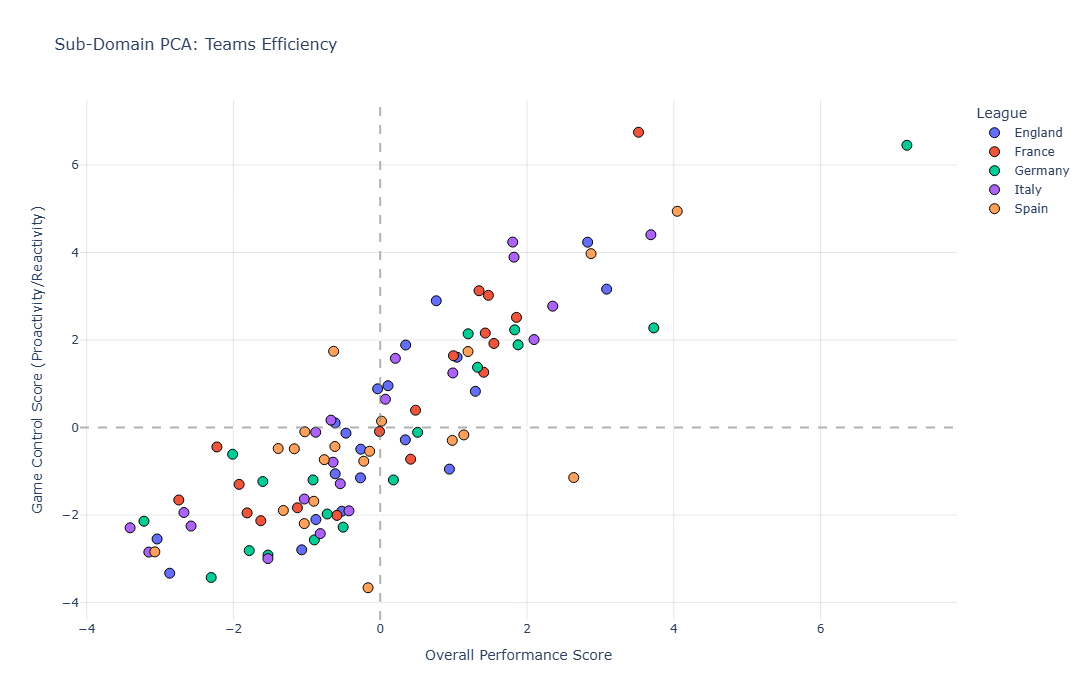

In [30]:
# Create Interactive Plotly Scatter Plot
fig = px.scatter(
    plot_df,
    x='Performance_Axis',
    y='Game_Control_Axis',
    color='League',
    hover_name='Team',
    hover_data={
        'Performance_Axis': ':.2f',
        'Game_Control_Axis': ':.2f',
        'League': True,
    },
    title='Sub-Domain PCA: Teams Efficiency',
    labels={
        'Performance_Axis': 'Overall Performance Score',
        'Game_Control_Axis': 'Game Control Score (Proactivity/Reactivity)',
    },
    width=1000,
    height=700,
)

# Add reference crosshair lines at coordinate (0,0)
fig.add_hline(y=0, line_dash='dash', line_color='gray', opacity=0.6)
fig.add_vline(x=0, line_dash='dash', line_color='gray', opacity=0.6)

fig.update_traces(marker=dict(size=10, line=dict(width=1, color='black')))

# Fixed grid properties applied correctly to x and y axes
fig.update_layout(
    title_font_size=16,
    plot_bgcolor='white',
)
fig.update_xaxes(showgrid=True, gridcolor='rgba(0,0,0,0.1)')
fig.update_yaxes(showgrid=True, gridcolor='rgba(0,0,0,0.1)')

# Render the interactive chart
fig.show()
#fig.write_html("Leagues_chart.html")

In [31]:
copy_plot_df = plot_df.copy()

In [32]:
df_cluster = copy_plot_df.merge(df_gamecontrol_clustered[['Team', 'Cluster_Game_Control']], on = 'Team', how ='right')

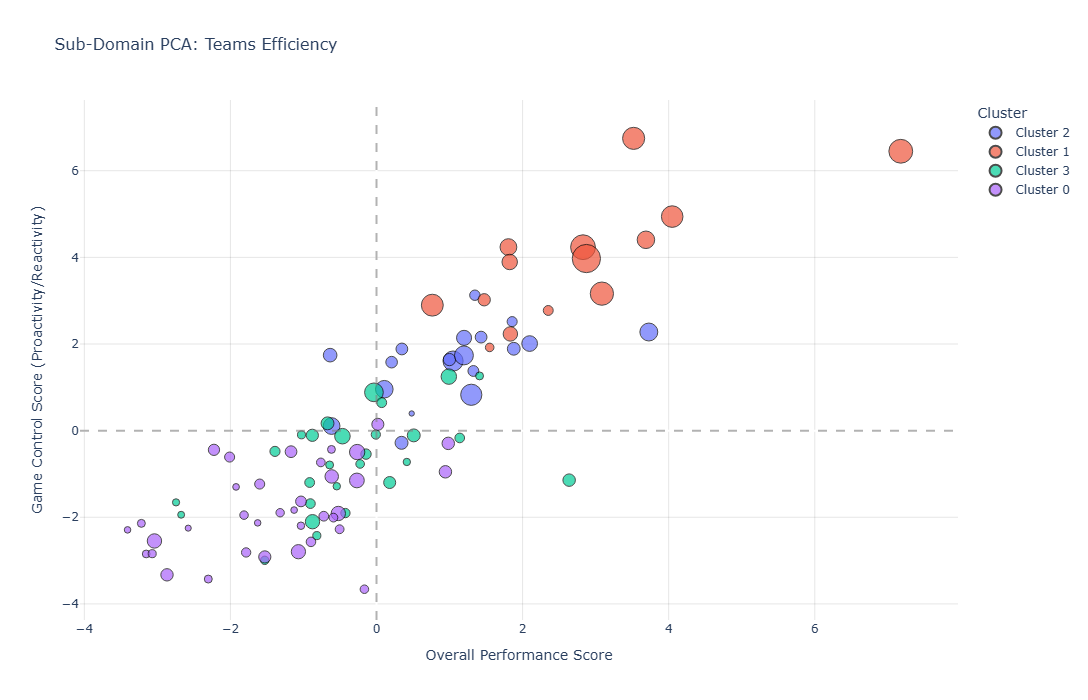

In [34]:
# 1. Convert cluster column to string/categorical with a label prefix
df_cluster['Cluster_Label'] = 'Cluster ' + df_cluster['Cluster_Game_Control'].astype(str)

# 2. Create the Scatter Plot
fig = px.scatter(
    df_cluster,
    x='Performance_Axis',
    y='Game_Control_Axis',
    color='Cluster_Label',
    size='Average_salary(€m)',     
    #trendline="ols",
    hover_name='Team',
    hover_data={
        'Performance_Axis': ':.2f',
        'Game_Control_Axis': ':.2f',
        'League': True,
        'Cluster_Label': False,         
    },
    title='Sub-Domain PCA: Teams Efficiency',
    labels={
        'Performance_Axis': 'Overall Performance Score',
        'Game_Control_Axis': 'Game Control Score (Proactivity/Reactivity)',
        'Cluster_Label': 'Cluster',
    },
    width=1000,
    height=700,
)

# Reference crosshair lines
fig.add_hline(y=0, line_dash='dash', line_color='gray', opacity=0.6)
fig.add_vline(x=0, line_dash='dash', line_color='gray', opacity=0.6)

# FIXED: Removed 'size=10' and targeted only the scatter markers so trendlines remain untouched
fig.update_traces(marker=dict(line=dict(width=1, color='black')), selector=dict(mode='markers'))

fig.update_layout(
    title_font_size=16,
    plot_bgcolor='white',
)
fig.update_xaxes(showgrid=True, gridcolor='rgba(0,0,0,0.1)')
fig.update_yaxes(showgrid=True, gridcolor='rgba(0,0,0,0.1)')

fig.show()
#fig.write_html("Clusters_chart.html")

In [35]:
import scipy.stats as stats

# Group the performance scores by cluster
cluster_groups = [df_cluster['Game_Control_Axis'][df_cluster['Cluster_Game_Control'] == i] for i in range(4)]

# Run One-Way ANOVA
f_stat, p_value = stats.f_oneway(*cluster_groups)

print(f"ANOVA F-statistic: {f_stat:.2f}")
print(f"P-value: {p_value:}")

ANOVA F-statistic: 115.54
P-value: 4.3159462842615435e-31


Strong Effect / Clear Separation: An F-statistic as high as 46.89 relative to typical degrees of freedom means the variance between your groups is substantially larger than the variance within the groups.

Practical Meaning: Whichever categorical groups or treatments you are testing using your PCA metrics, they are distinct from one another. Your principal components are successfully capturing underlying differences that separate these groups.

In [40]:
import plotly.express as px

euro_league = ['England', 'Spain', 'France', 'Italy', 'Germany']

# 1. Store dataframes in a dictionary
df_dict = {}
for element in euro_league:
    df_dict[element] = df_cluster.loc[df_cluster['League'] == element].copy()

# Start an empty HTML string to hold all your graphs
combined_html = '<html><head><title>All Leagues Dashboard</title></head><body>'

# 2. Loop through, create each chart, and append its HTML
for i, element in enumerate(euro_league):
    fig = px.scatter(
        data_frame=df_dict[element], 
        x='Average_salary(€m)', 
        y='Performance_Axis',
        hover_name='Team',
        hover_data={
        'Average_salary(€m)': ':.2f',
        'Performance_Axis': ':.2f'},
        trendline='ols',  # Adds the linear regression line
        title=f'Salary vs Performance: {element}'
    )
    
    # Include Plotly.js library on the first chart only; exclude on the rest
    include_js = 'cdn' if i == 0 else False
    
    # Add this figure's HTML to our master string
    combined_html += fig.to_html(full_html=False, include_plotlyjs=include_js)

# Close the HTML tags
combined_html += '</body></html>'

# 3. Write everything to a single file once the loop is done
with open('all_leagues_dashboard.html', 'w', encoding='utf-8') as f:
    f.write(combined_html)

print("Dashboard successfully saved as 'all_leagues_dashboard.html'!")

Dashboard successfully saved as 'all_leagues_dashboard.html'!


In [ ]:
import plotly.express as px

euro_league = ['England', 'Spain', 'France', 'Italy', 'Germany']

# 1. Store dataframes in a dictionary
df_dict = {}
for element in euro_league:
    df_dict[element] = df_cluster.loc[df_cluster['League'] == element].copy()

# Start an empty HTML string to hold all your graphs
combined_html = '<html><head><title>All Leagues Dashboard</title></head><body>'

# 2. Loop through, create each chart, and append its HTML
for i, element in enumerate(euro_league):
    fig = px.scatter(
        data_frame=df_dict[element], 
        x='Performance_Axis', 
        y='Game_Control_Axis',
        hover_name='Team',
        hover_data={
        'Performance_Axis': ':.2f',
        'Game_Control_Axis': ':.2f'},
        trendline='ols',  # Adds the linear regression line
        title=f'Game Control vs Performance: {element}'
    )
    
    # Include Plotly.js library on the first chart only; exclude on the rest
    include_js = 'cdn' if i == 0 else False
    
    # Add this figure's HTML to our master string
    combined_html += fig.to_html(full_html=False, include_plotlyjs=include_js)

# Close the HTML tags
combined_html += '</body></html>'

# 3. Write everything to a single file once the loop is done
with open('all_leagues_dashboard.html', 'w', encoding='utf-8') as f:
    f.write(combined_html)

print("Dashboard successfully saved as 'all_leagues_dashboard.html'!")

In [41]:
df_europe = df_cluster[['League', 'Team', 'Cluster_Label']]

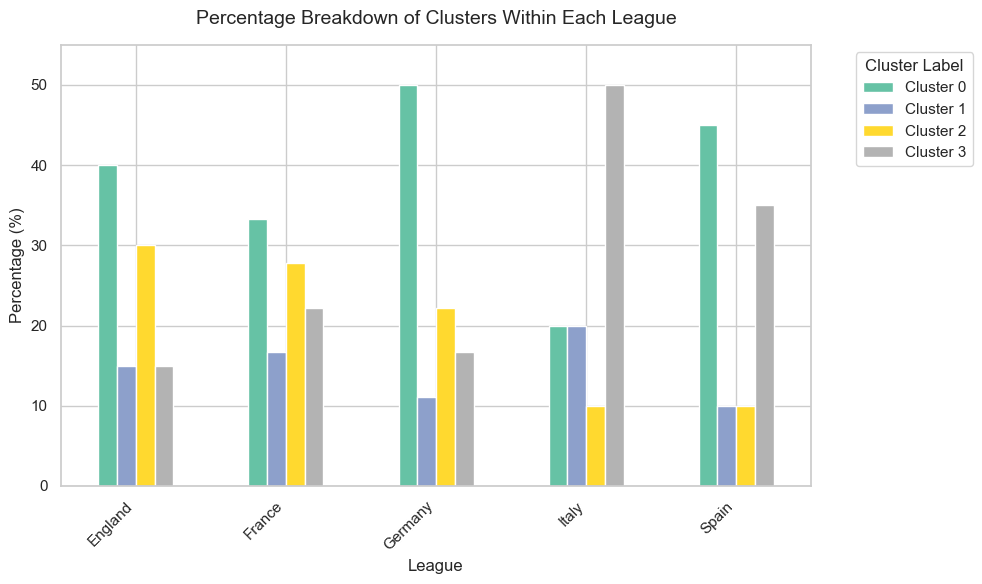

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create a crosstab (contingency table) of League vs Cluster_Label
ct = pd.crosstab(df_europe['League'], df_europe['Cluster_Label'])

# 2. Convert the counts to percentages row-wise (within each league)
ct_percentage = ct.div(ct.sum(axis=1), axis=0) * 100

# 3. Plot the stacked bar chart
ax = ct_percentage.plot(kind='bar', stacked=False, figsize=(10, 6), colormap='Set2')

# Customize the chart
plt.title('Percentage Breakdown of Clusters Within Each League', fontsize=14, pad=15)
plt.xlabel('League', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.legend(title='Cluster Label', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 55)
plt.tight_layout()

# Display the chart
plt.show()

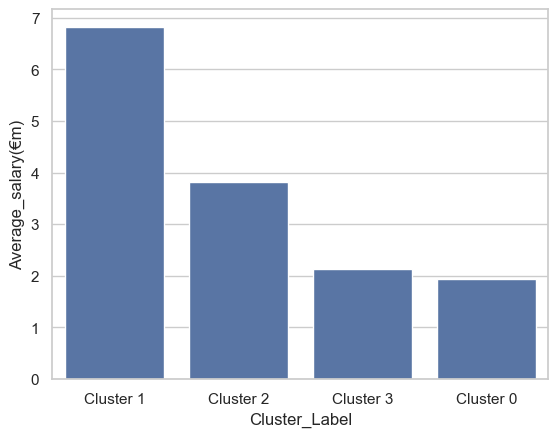

In [45]:
by_cluster = df_cluster[['Cluster_Label', 'Average_salary(€m)']].groupby('Cluster_Label').mean().sort_values(by = 'Average_salary(€m)', ascending = False)
plt.figure()
sns.barplot(data = by_cluster, x= 'Cluster_Label', y = 'Average_salary(€m)')
plt.show()

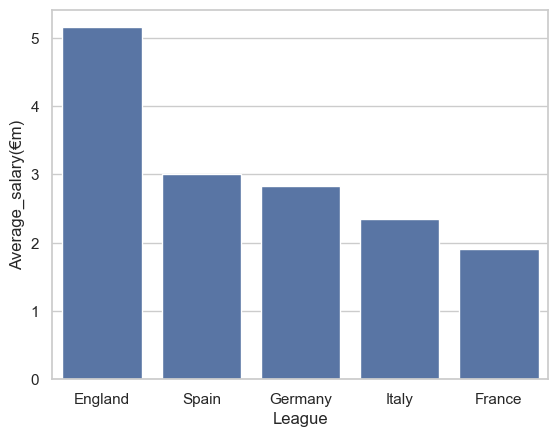

In [46]:
df_league = df_cluster[['League', 'Average_salary(€m)']].groupby('League').mean().sort_values(by = 'Average_salary(€m)', ascending = False)
plt.figure()
sns.barplot(data = df_league, x = 'League', y = 'Average_salary(€m)')
plt.show()

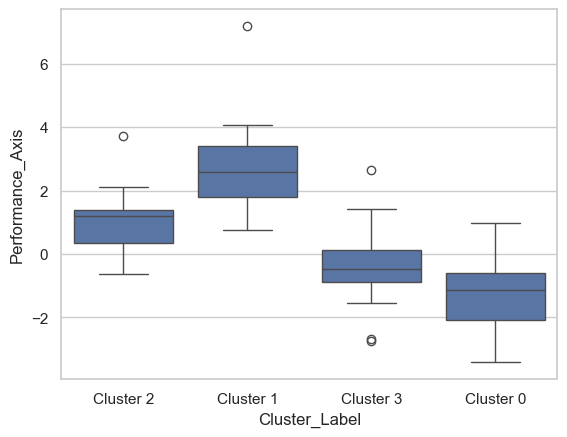

In [47]:
plt.figure()
sns.boxplot(data = df_cluster, x = 'Cluster_Label', y = 'Performance_Axis')
plt.show()

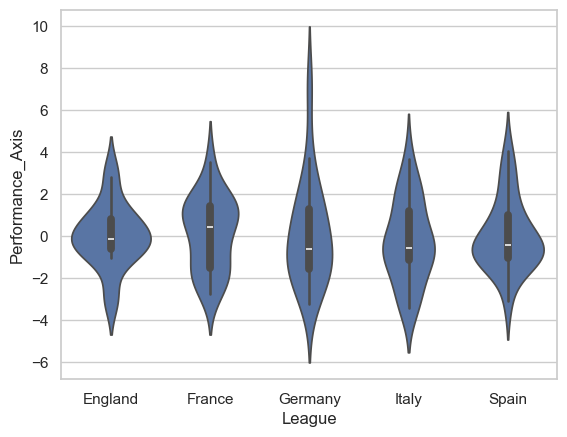

In [48]:
plt.figure()
sns.violinplot(data = df_cluster, x = 'League', y = 'Performance_Axis')
plt.show()

In [59]:
df_final = df_cluster.merge(df[['Team','Goals_scored/90','xG/90','Goals_conceded/90', 'xG_conceded/90','Shot_conversion_rate(%)',
    'Big_chances_conversion rate','Possession(%)','Pass/90','Long_balls/90','Crosses/90','Clearances/90',
    'Possession_won_midfield/90','Possession_won_attacking_3rd/90','Touches_in_opposition_box/90','Tackles/90','Interceptions/90','Saves/90']],
                            on = 'Team', how ='right')

In [68]:
df_final = df_final.drop(columns = 'Cluster_Game_Control')

In [70]:
#Export Final dataframe for dashboard preparation
#df_final.to_csv('final_dashboard_data.csv', index=False)